In [8]:
import numpy as np
import pandas as pd

trainX = pd.read_csv("X_train.txt", sep=r'\s+', header=None )
testX = pd.read_csv("X_test.txt", sep=r'\s+',header=None )

xVar = pd.concat([trainX, testX], ignore_index=True)

In [14]:
import pandas as pd

trainY = pd.read_csv("y_train.txt", sep=r'\s+', header=None )
testY = pd.read_csv("y_test.txt", sep=r'\s+',header=None )

yVar = pd.concat([trainY, testY], ignore_index=True)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler();
scaledX = scaler.fit_transform(xVar)



In [16]:
from sklearn.decomposition import PCA

pcaLittle = PCA(n_components=2)
pcaXLittle = pcaLittle.fit_transform(scaledX)

pcaBigger = PCA(n_components=50)
pcaXBigger = pcaBigger.fit_transform(scaledX)


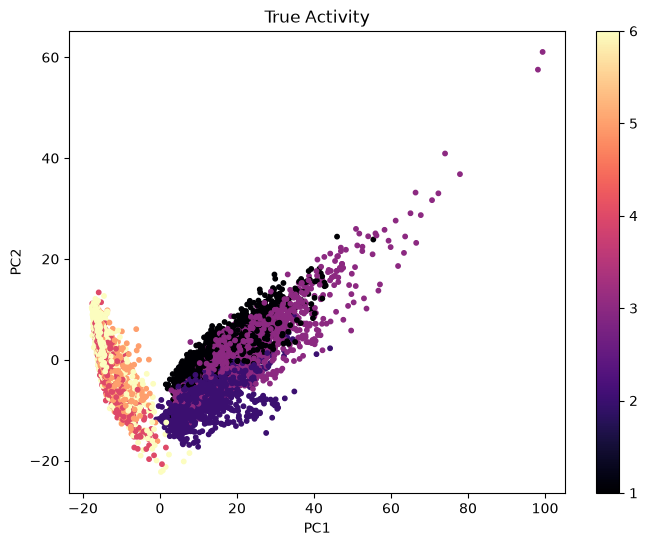

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))
plt.scatter(pcaXLittle[:,0], pcaXBigger[:,1], c=yVar.values.ravel(), cmap="magma", s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("True Activity")
plt.colorbar()
plt.show()


In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=40)
clustering = kmeans.fit_predict(pcaXLittle)

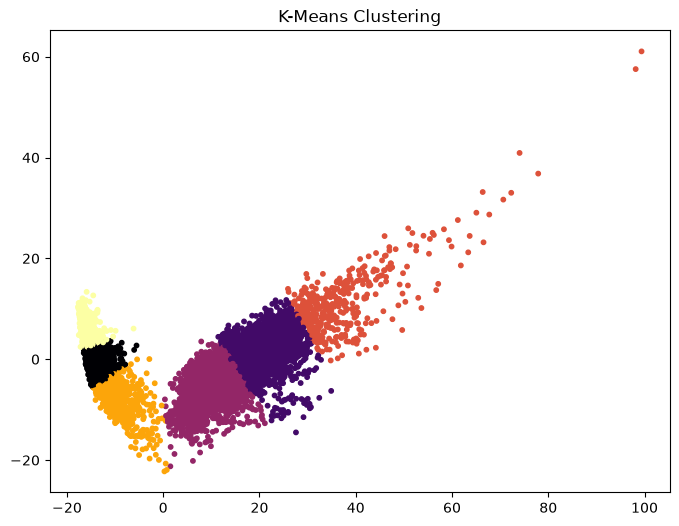

In [61]:
plt.figure(figsize = (8,6))
plt.scatter(pcaXLittle[:,0], pcaXBigger[:,1], c=clustering, cmap="inferno", s=10)

plt.title("K-Means Clustering")
plt.show()

In [38]:
from sklearn.metrics import silhouette_score

silScore = silhouette_score(pcaXBigger,clustering)
print(silScore)

print (kmeans.inertia_)

kExp = range(2,12)
inertia =[]
silhoette = []

for k in kExp:
    myModel = KMeans(n_clusters=k, random_state=40)

    labels = myModel.fit_predict(pcaXBigger)
    inertia.append(myModel.inertia_)

    silhoette.append(silhouette_score(pcaXBigger, labels))

0.11757965497820924
220572.3508148869


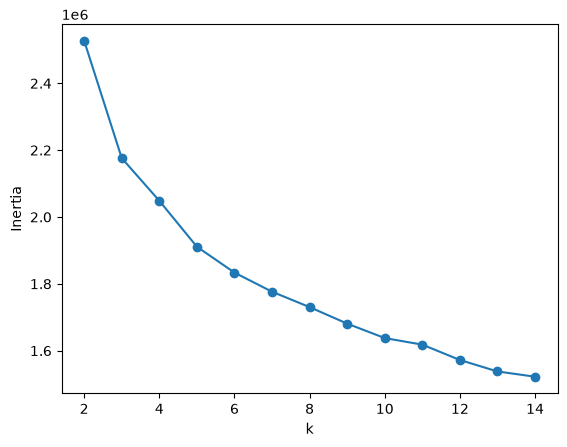

In [39]:
plt.plot(kExp, inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

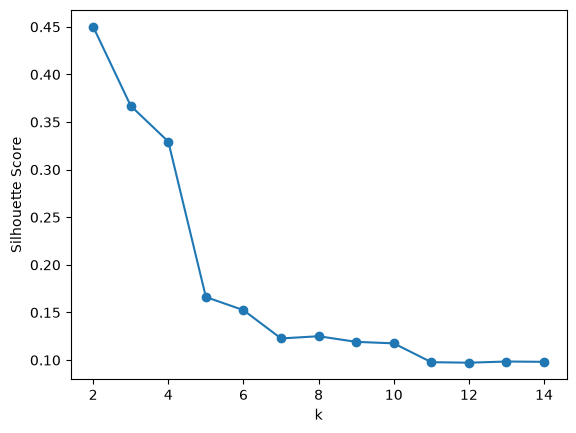

In [40]:
plt.plot(kExp, silhoette, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

In [42]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(pcaXBigger)

if len(set(labels)) >1:
    score = silhouette_score(pcaXBigger, labels)
    print(score)

In [54]:
someValues= [.1, .2, .3, .4, .5, .6, .7, .8, .9]
minValues = [5,10,15,20]
bestNum = -1
bestParam = None
bestLabels = None

for val in someValues:
        for m in minValues:
            db = DBSCAN(eps =val,min_samples=m )

            labels= db.fit_predict(pcaXBigger)

            if len(set(labels)) >1:
                score = silhouette_score(pcaXBigger, labels)

                if score> bestNum:
                    bestNum = score
                    bestParam = (val,m)
                    bestLabels = labels

print("Best silhouette", bestNum)
print("Best param", bestParam)

Best silhouette -1
Best param None


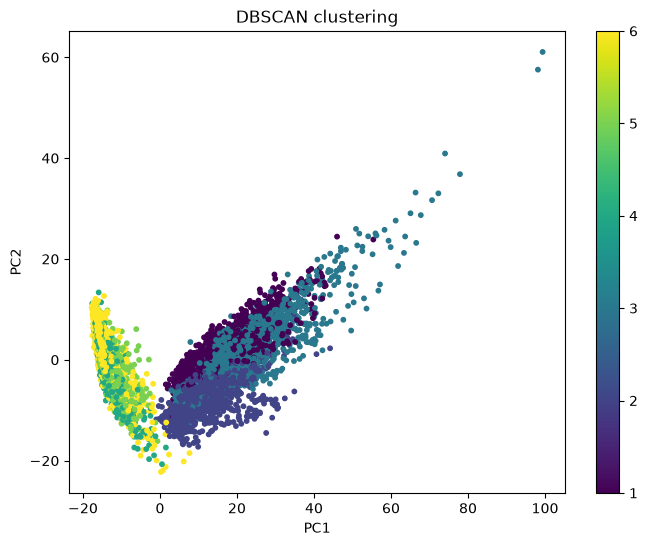

In [63]:
plt.figure(figsize = (8,6))
plt.scatter(pcaXLittle[:,0], pcaXLittle[:,1], c=yVar.values.ravel(), cmap="viridis", s=10)

plt.title("DBSCAN clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()

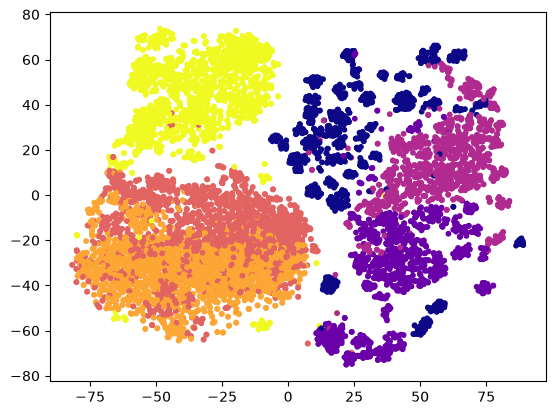

In [57]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=40)

xTSNE = tsne.fit_transform(pcaXBigger)

plt.scatter(xTSNE[:,0],xTSNE[:,1], c=yVar.values.ravel(), cmap="plasma", s=10)